<a href="https://colab.research.google.com/github/ZorahSai/Projeto-WebAgriculture-/blob/main/Coleta%20de%20Dados/Coleta_de_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Template — Ingestão de dados via API RIPE Atlas

**Objetivo:** consumir resultados de uma medição pública da API RIPE Atlas, receber os dados em JSON, transformá-los em um `DataFrame` e salvar a coleta no Google Drive.

> Este notebook cobre **somente a ingestão e o armazenamento da camada `raw`**. Não agregue janelas, não crie variáveis, não rotule dados e não treine modelos nesta etapa.

## Entrega mínima

- Justificar as decisões da equipe sobre os parâmetros da consulta;
- Executar uma requisição válida à API;
- Exibir os dados em um `DataFrame`;
- Salvar o JSON original da resposta;
- Salvar os registros em **CSV ou Parquet** na pasta `raw` do Google Drive;
- Registrar evidências da coleta: URL, parâmetros, horário, quantidade de registros e nomes dos arquivos.


## Pipeline da fase de coleta e ingestão

O desenho abaixo apresenta o percurso desta etapa, desde a escolha da medição pública até a verificação dos arquivos salvos na pasta `raw`. Se a consulta não for válida, a equipe deverá revisar os parâmetros e realizar uma nova tentativa.


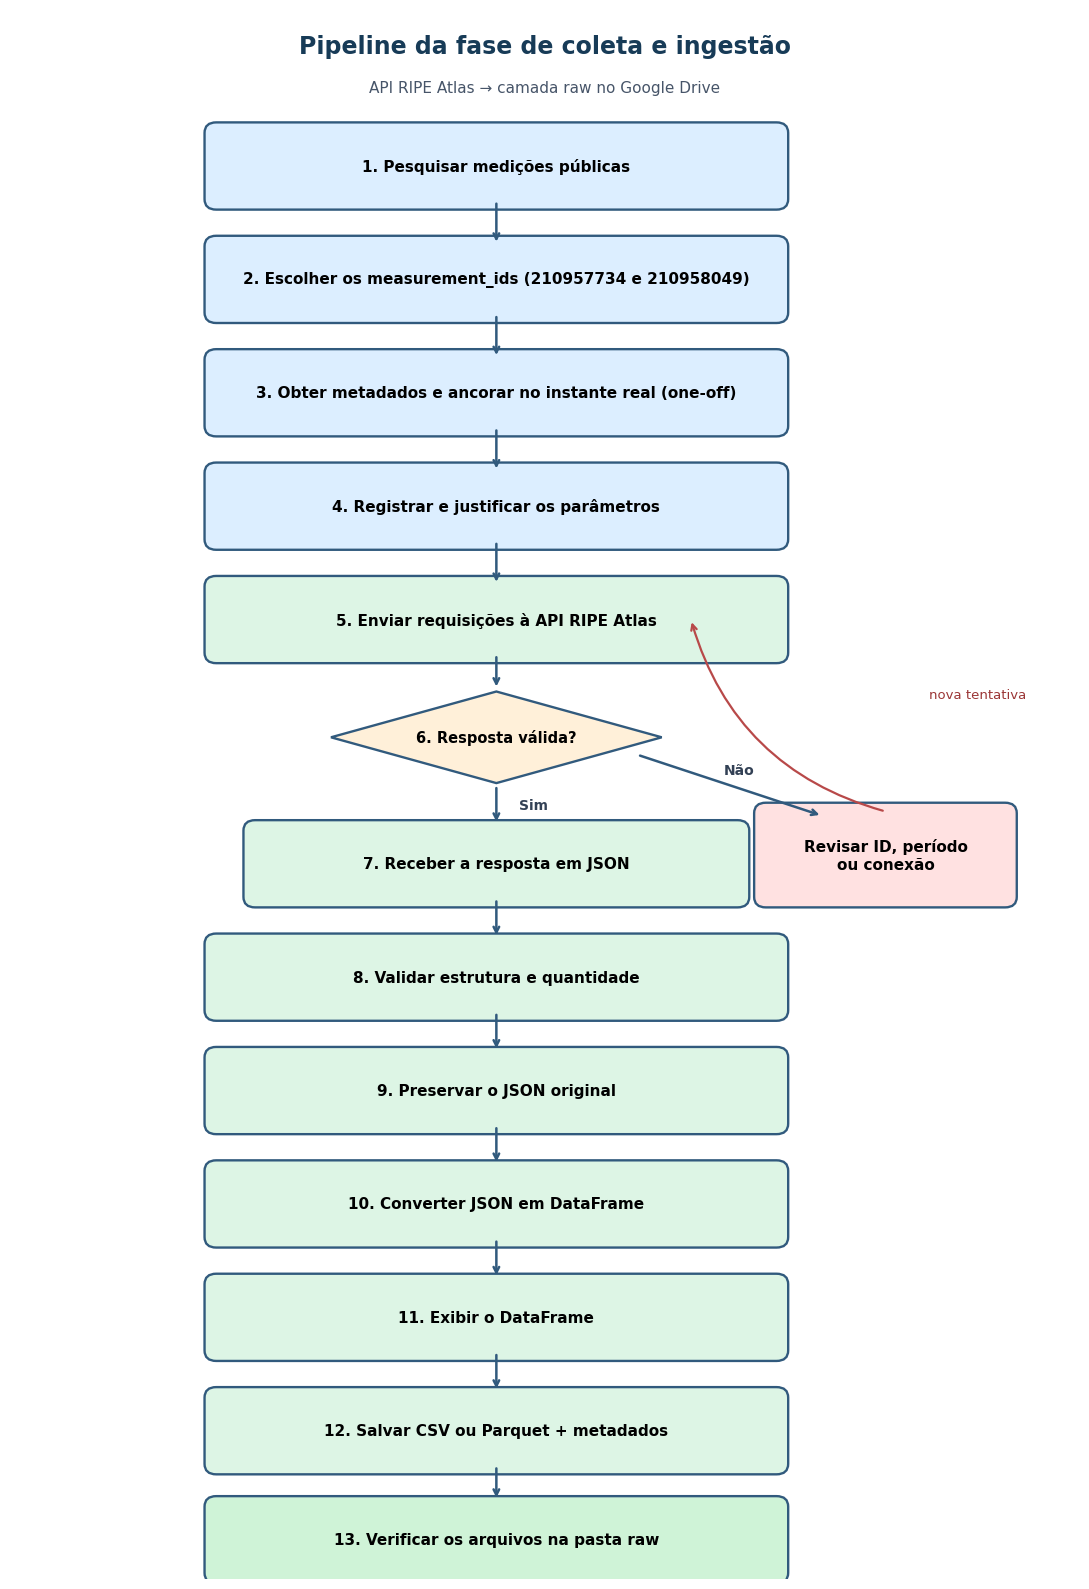

In [12]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Polygon

# Desenho do pipeline da fase de coleta e ingestão
fig, ax = plt.subplots(figsize=(11, 16))
ax.set_xlim(0, 11)
ax.set_ylim(0, 18)
ax.axis("off")

azul = "#DCEEFF"
verde = "#DDF5E5"
laranja = "#FFF0D9"
vermelho = "#FFE1E1"
borda = "#315A7D"

def caixa(x, y, texto, cor=azul, largura=5.8, altura=0.8):
    forma = FancyBboxPatch(
        (x - largura / 2, y - altura / 2), largura, altura,
        boxstyle="round,pad=0.10,rounding_size=0.12",
        linewidth=1.7, edgecolor=borda, facecolor=cor
    )
    ax.add_patch(forma)
    ax.text(x, y, texto, ha="center", va="center", fontsize=11, weight="bold")

def decisao(x, y, texto):
    largura, altura = 3.4, 1.05
    pontos = [(x, y + altura/2), (x + largura/2, y),
              (x, y - altura/2), (x - largura/2, y)]
    ax.add_patch(Polygon(pontos, closed=True, edgecolor=borda,
                         facecolor=laranja, linewidth=1.7))
    ax.text(x, y, texto, ha="center", va="center", fontsize=10.5, weight="bold")

def seta(x1, y1, x2, y2, rotulo=None, deslocamento=(0, 0)):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.8, color=borda))
    if rotulo:
        ax.text((x1+x2)/2 + deslocamento[0], (y1+y2)/2 + deslocamento[1],
                rotulo, fontsize=10, weight="bold", color="#334155",
                ha="center", va="center")

ax.text(5.5, 17.5, "Pipeline da fase de coleta e ingestão",
        ha="center", fontsize=17, weight="bold", color="#173B57")
ax.text(5.5, 17.05, "API RIPE Atlas → camada raw no Google Drive",
        ha="center", fontsize=11, color="#475569")

etapas = [
    (16.2, "1. Pesquisar medições públicas", azul),
    (14.9, "2. Escolher os measurement_ids (210957734 e 210958049)", azul),
    (13.6, "3. Obter metadados e ancorar no instante real (one-off)", azul),
    (12.3, "4. Registrar e justificar os parâmetros", azul),
    (11.0, "5. Enviar requisições à API RIPE Atlas", verde),
]
for y, texto, cor in etapas:
    caixa(5, y, texto, cor)

for y1, y2 in [(15.8, 15.3), (14.5, 14.0), (13.2, 12.7), (11.9, 11.4)]:
    seta(5, y1, 5, y2)

decisao(5, 9.65, "6. Resposta válida?")
seta(5, 10.6, 5, 10.2)

# Caminho de erro e nova tentativa
caixa(9.0, 8.3, "Revisar ID, período\nou conexão", vermelho, largura=2.5, altura=1.0)
seta(6.45, 9.45, 8.35, 8.75, "Não", (0.10, 0.18))
ax.annotate("", xy=(7.0, 11.0), xytext=(9.0, 8.8),
            arrowprops=dict(arrowstyle="->", lw=1.6, color="#B84949",
                            connectionstyle="arc3,rad=-0.28"))
ax.text(9.45, 10.1, "nova tentativa", fontsize=9.5, color="#9B3636")

# Caminho principal
caixa(5, 8.2, "7. Receber a resposta em JSON", verde, largura=5.0)
seta(5, 9.1, 5, 8.65, "Sim", (0.38, 0))

caixa(5, 6.9, "8. Validar estrutura e quantidade", verde)
caixa(5, 5.6, "9. Preservar o JSON original", verde)
caixa(5, 4.3, "10. Converter JSON em DataFrame", verde)
caixa(5, 3.0, "11. Exibir o DataFrame", verde)
caixa(5, 1.7, "12. Salvar CSV ou Parquet + metadados", verde)
caixa(5, 0.45, "13. Verificar os arquivos na pasta raw", "#CFF3D7")

for y1, y2 in [(7.8, 7.35), (6.5, 6.05), (5.2, 4.75),
               (3.9, 3.45), (2.6, 2.15), (1.3, 0.9)]:
    seta(5, y1, 5, y2)

plt.tight_layout()
plt.show()


## 1. Identificação da equipe

Preencham antes de executar.

- **Equipe:** WebAgriculture
- **Integrantes:** Apollo Moura De Sousa, Icaro Luiz Dellalo Silva, Ieda de Oliveira, João Pedro C. de Morais, Lucas Matteus Baptista de Godoy.
- **Turma:** Ciência da Computação
- **Data da coleta:** 13/09/2026


## 2. Decisões da equipe

Cada equipe deve pesquisar e definir os próprios parâmetros. Registre abaixo:

| Decisão | Escolha da equipe | Justificativa |
|---|---|---|
| ID da medição (`measurement_id`) | ID 1 (210958049), ID 2 (210957734) | Variedade de cenários geográficos e de RTT (ver detalhamento abaixo) |
| Janela de busca (`start`/`stop` da API) | 5 minutos antes e 5 minutos depois do `start_time` real de cada medição | Cada medição one-off dispara uma única vez; a margem existe só para garantir que a resposta seja capturada mesmo com pequena variação de propagação entre sondas — não é uma coleta contínua de 2h. |
| Instante real da medição (one-off) | ID1 (210958049): 2026-09-13 17:54:32 – 2026-09-13 17:54:33 / ID2 (210957734): 2026-09-13 17:52:10 – 2026-09-13 17:52:16 | Como a medição é one-off, este é o dado que efetivamente caracteriza "quando" ela ocorreu — não a janela de busca, que é só um parâmetro técnico de filtro. |
| Tipo de medição | Ping (ONE-OFF) | Selecionado por ser o tipo mais direto para avaliar RTT e perda de pacotes, que eram justamente os critérios de comparação entre os dois IDs. Confirmado via campo `is_oneoff` retornado pela API (Seção 5). |
| Formato de saída: CSV ou Parquet | CSV | Optado por ser um formato leve, de fácil leitura tabular e compatível com praticamente qualquer ferramenta de análise (Excel, pandas, etc.), facilitando o tratamento posterior dos dados. |

Antes de escolher, consultem a documentação e verifiquem se a medição é pública, se o ID existe e se o intervalo solicitado possui resultados. Evitem períodos excessivamente longos: eles podem retornar muitos registros ou tornar a consulta lenta.

Justificativa detalhada dos IDs.

Foram escolhidos 2 IDs para que houvesse uma variedade maior de cenários a serem analisados. Ambas as escolhas foram feitas por respeitarem os requisitos de serem medições públicas, IDs existentes e com resultados sólidos, além de apresentarem um contraste relacionado à diferença de RTT médio nas duas e da área geográfica de cada uma.

O ID 1 apresenta resultados de medições feitas em uma área geográfica ampla dentro do continente asiático. Na nossa interpretação, isso pode ser a principal causa para a média mínima de RTT ser superior a 100ms. A validação da coleta (Seção 7) confirmou 1 sonda com timeout total e 10 pacotes individuais perdidos nessa medição, o que também contribuiu para a escolha como exemplo de falha real de rede.

O ID 2 abrange uma área geográfica menor se comparada ao ID 1, com probes na América do Norte e do Sul. Por ser uma área menor, esperava-se que a média mínima de RTT fosse menor, o que de fato se comprovou. A validação da coleta (Seção 7) não identificou duplicatas, timeouts ou pacotes perdidos nessa medição.

## 3. Bibliotecas

As bibliotecas abaixo são sugestões para esta etapa. O `pyarrow` é necessário apenas se a equipe escolher Parquet.


In [13]:
# Execute esta instalação se for usar o formato Parquet.
!pip -q install pyarrow


In [14]:
import json
import time
from datetime import datetime, timedelta, timezone
from pathlib import Path

import pandas as pd
import requests

print("Bibliotecas carregadas.")


Bibliotecas carregadas.


## 4. Montar o Google Drive e preparar a pasta `raw`

O caminho sugerido cria a pasta `ripe_atlas/raw` dentro de `Meu Drive`. A equipe pode alterar somente a pasta do projeto, mantendo uma subpasta chamada `raw`.


In [15]:
import sys

if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    PASTA_PROJETO = Path("/content/drive/MyDrive/ripe_atlas")
else:
    PASTA_PROJETO = Path("./ripe_atlas")  # pasta local, dentro do repositório/projeto

PASTA_RAW = PASTA_PROJETO / "raw"
PASTA_RAW.mkdir(parents=True, exist_ok=True)

print("Arquivos raw serão salvos em:", PASTA_RAW)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Arquivos raw serão salvos em: /content/drive/MyDrive/ripe_atlas/raw


## 5. Função de coleta (parametrizada para os dois IDs)

Como a equipe consulta duas medições (210957734 e 210958049), a lógica de
consulta, transformação e salvamento foi encapsulada em uma função. Isso evita
duplicar código e garante que as duas coletas sigam exatamente o mesmo processo.

In [16]:
def obter_metadados_medicao(measurement_id, timeout_requisicao):
    url_metadados = f"https://atlas.ripe.net/api/v2/measurements/{measurement_id}/"
    response = requests.get(url_metadados, timeout=timeout_requisicao)
    response.raise_for_status()
    info = response.json()
    return {
        "is_oneoff": info.get("is_oneoff"),
        "interval": info.get("interval"),
        "packets": info.get("packets"),
        "start_time": info.get("start_time"),
        "stop_time": info.get("stop_time"),
    }


def coletar_medicao_ripe(measurement_id, formato_tabelar, timeout_requisicao, pasta_raw, margem_minutos=5):
    print(f"\n=== Medição {measurement_id} ===")

    metadados_medicao = obter_metadados_medicao(measurement_id, timeout_requisicao)
    print("is_oneoff:", metadados_medicao["is_oneoff"])
    print("interval:", metadados_medicao["interval"])
    print("packets:", metadados_medicao["packets"])

    inicio_real = datetime.fromtimestamp(metadados_medicao["start_time"], tz=timezone.utc)
    inicio_utc = inicio_real - timedelta(minutes=margem_minutos)
    fim_utc = inicio_real + timedelta(minutes=margem_minutos)

    url = f"https://atlas.ripe.net/api/v2/measurements/{measurement_id}/results/"
    parametros = {"start": int(inicio_utc.timestamp()), "stop": int(fim_utc.timestamp())}

    assert isinstance(measurement_id, int) and measurement_id > 0
    assert formato_tabelar in {"csv", "parquet"}

    print("URL:", url)
    print("Início (UTC):", inicio_utc.isoformat())
    print("Fim (UTC):", fim_utc.isoformat())

    instante_requisicao_utc = datetime.now(timezone.utc)
    try:
        response = requests.get(url, params=parametros, timeout=timeout_requisicao)
        response.raise_for_status()
        dados_json = response.json()
    except requests.exceptions.Timeout as erro:
        raise RuntimeError("A API não respondeu dentro do tempo definido.") from erro
    except requests.exceptions.HTTPError as erro:
        raise RuntimeError(f"Erro HTTP {response.status_code}. Verifique o ID e os parâmetros.") from erro

    print(f"Status HTTP: {response.status_code}")
    print(f"Quantidade de registros recebidos: {len(dados_json)}")

    df_raw = pd.json_normalize(dados_json, sep="_")
    print("Dimensões do DataFrame (linhas, colunas):", df_raw.shape)
    display(df_raw.head())

    horarios = df_raw["timestamp"].apply(lambda t: datetime.fromtimestamp(t, tz=timezone.utc))
    print("Instante mais antigo reportado:", horarios.min())
    print("Instante mais recente reportado:", horarios.max())
    print("Amplitude entre a primeira e a última sonda:", horarios.max() - horarios.min())

    total_sondas = (
        df_raw["prb_id"].nunique() if "prb_id" in df_raw.columns else 0
    )
    duplicatas = (
        df_raw.duplicated(subset=["prb_id", "timestamp"]).sum()
        if {"prb_id", "timestamp"}.issubset(df_raw.columns)
        else 0
    )
    sondas_timeout_total = (
        (df_raw["rcvd"] == 0).sum() if "rcvd" in df_raw.columns else 0
    )

    # Contagem de pacotes perdidos sinalizados com "x"
    pacotes_perdidos = sum(
        1
        for reg in dados_json
        for resp in reg.get("result", [])
        if isinstance(resp, dict) and "x" in resp
    )

    print("\n--- Validação de Integridade ---")
    print(f"  • Sondas distintas (prb_id): {total_sondas}")
    print(f"  • Registros duplicados: {duplicatas}")
    print(f"  • Sondas com timeout total (rcvd==0): {sondas_timeout_total}")
    print(f"  • Pacotes perdidos ('x'): {pacotes_perdidos}\n")

    timestamp_arquivo = instante_requisicao_utc.strftime("%Y%m%dT%H%M%SZ")
    nome_base = f"ripe_atlas_m{measurement_id}_{timestamp_arquivo}"

    caminho_json = pasta_raw / f"{nome_base}.json"
    with caminho_json.open("w", encoding="utf-8") as arquivo:
        json.dump(dados_json, arquivo, ensure_ascii=False, indent=2)

    if formato_tabelar == "csv":
        caminho_tabela = pasta_raw / f"{nome_base}.csv"
        df_raw.to_csv(caminho_tabela, index=False, encoding="utf-8")
    else:
        caminho_tabela = pasta_raw / f"{nome_base}.parquet"
        df_raw.to_parquet(caminho_tabela, index=False)

    metadados = {
        "measurement_id": measurement_id,
        "is_oneoff": metadados_medicao["is_oneoff"],
        "interval": metadados_medicao["interval"],
        "packets": metadados_medicao["packets"],
        "url": url,
        "parametros": parametros,
        "inicio_utc": inicio_utc.isoformat(),
        "fim_utc": fim_utc.isoformat(),
        "coletado_em_utc": instante_requisicao_utc.isoformat(),
        "status_http": response.status_code,
        "quantidade_registros": len(dados_json),
        "quantidade_colunas_dataframe": len(df_raw.columns),
        "arquivo_json": caminho_json.name,
        "arquivo_tabelar": caminho_tabela.name,
    }
    caminho_metadados = pasta_raw / f"{nome_base}_metadata.json"
    with caminho_metadados.open("w", encoding="utf-8") as arquivo:
        json.dump(metadados, arquivo, ensure_ascii=False, indent=2)

    assert caminho_json.exists(), "O arquivo JSON não foi encontrado."
    assert caminho_tabela.exists(), "O arquivo CSV/Parquet não foi encontrado."
    assert caminho_metadados.exists(), "O arquivo de metadados não foi encontrado."

    print("JSON original:", caminho_json)
    print("Arquivo tabular:", caminho_tabela)
    print("Metadados:", caminho_metadados)

    return {"df_raw": df_raw, "dados_json": dados_json, "metadados_medicao": metadados_medicao,
            "caminho_json": caminho_json, "caminho_tabela": caminho_tabela, "caminho_metadados": caminho_metadados}

    resultado_210957734 = coletar_medicao_ripe(
    210957734, "csv", timeout_requisicao=30, pasta_raw=PASTA_RAW
    )
    resultado_210958049 = coletar_medicao_ripe(
    210958049, "csv", timeout_requisicao=30, pasta_raw=PASTA_RAW
    )

## 6. Parâmetros e execução da coleta

In [17]:
FORMATO_TABELAR = "csv"
TIMEOUT_REQUISICAO = 60
MARGEM_MINUTOS = 5

resultado_210957734 = coletar_medicao_ripe(210957734, FORMATO_TABELAR, TIMEOUT_REQUISICAO, PASTA_RAW, MARGEM_MINUTOS)
resultado_210958049 = coletar_medicao_ripe(210958049, FORMATO_TABELAR, TIMEOUT_REQUISICAO, PASTA_RAW, MARGEM_MINUTOS)


=== Medição 210957734 ===
is_oneoff: True
interval: None
packets: 3
URL: https://atlas.ripe.net/api/v2/measurements/210957734/results/
Início (UTC): 2026-09-13T17:47:07+00:00
Fim (UTC): 2026-09-13T17:57:07+00:00
Status HTTP: 200
Quantidade de registros recebidos: 8
Dimensões do DataFrame (linhas, colunas): (8, 26)


,fw,mver,lts,dst_name,af,dst_addr,src_addr,proto,ttl,size,...,avg,msm_id,prb_id,timestamp,msm_name,from,type,group_id,step,stored_timestamp
0,5060,2.5.1,26,96.216.85.53,4,96.216.85.53,192.168.88.251,ICMP,50,64,...,66.027282,210957734,1003790,1789321932,Ping,190.122.166.242,ping,210957734,None,1789321933
1,5110,2.6.4,26,96.216.85.53,4,96.216.85.53,64.247.129.23,ICMP,51,64,...,98.085349,210957734,1011402,1789321932,Ping,64.247.129.23,ping,210957734,None,1789321933
2,5080,2.6.2,40,96.216.85.53,4,96.216.85.53,172.16.3.244,ICMP,51,64,...,56.689799,210957734,61048,1789321932,Ping,66.248.183.139,ping,210957734,None,1789321932
3,5120,2.6.4,33,96.216.85.53,4,96.216.85.53,10.42.0.15,ICMP,50,64,...,42.721591,210957734,1013022,1789321933,Ping,173.224.240.24,ping,210957734,None,1789321934
4,5080,2.6.2,36,96.216.85.53,4,96.216.85.53,192.168.1.2,ICMP,46,64,...,97.462089,210957734,25182,1789321936,Ping,177.249.173.159,ping,210957734,None,1789321934


Instante mais antigo reportado: 2026-09-13 17:52:10+00:00
Instante mais recente reportado: 2026-09-13 17:52:16+00:00
Amplitude entre a primeira e a última sonda: 0 days 00:00:06

--- Validação de Integridade ---
  • Sondas distintas (prb_id): 8
  • Registros duplicados: 0
  • Sondas com timeout total (rcvd==0): 0
  • Pacotes perdidos ('x'): 0

JSON original: /content/drive/MyDrive/ripe_atlas/raw/ripe_atlas_m210957734_20261008T060933Z.json
Arquivo tabular: /content/drive/MyDrive/ripe_atlas/raw/ripe_atlas_m210957734_20261008T060933Z.csv
Metadados: /content/drive/MyDrive/ripe_atlas/raw/ripe_atlas_m210957734_20261008T060933Z_metadata.json

=== Medição 210958049 ===
is_oneoff: True
interval: None
packets: 10
URL: https://atlas.ripe.net/api/v2/measurements/210958049/results/
Início (UTC): 2026-09-13T17:49:21+00:00
Fim (UTC): 2026-09-13T17:59:21+00:00
Status HTTP: 200
Quantidade de registros recebidos: 16
Dimensões do DataFrame (linhas, colunas): (16, 26)


,fw,mver,lts,dst_name,af,dst_addr,src_addr,proto,ttl,size,...,avg,msm_id,prb_id,timestamp,msm_name,from,type,group_id,step,stored_timestamp
0,5080,2.6.2,55,103.149.39.14,4,103.149.39.14,192.168.5.104,ICMP,51.0,64,...,240.794719,210958049,20980,1789322072,Ping,79.170.160.253,ping,210958049,None,1789322073
1,5080,2.6.3,38,103.149.39.14,4,103.149.39.14,94.204.188.69,ICMP,52.0,64,...,228.768509,210958049,1000245,1789322072,Ping,94.204.188.69,ping,210958049,None,1789322073
2,5130,2.6.4,26,103.149.39.14,4,103.149.39.14,172.17.0.7,ICMP,49.0,64,...,562.925418,210958049,1010769,1789322072,Ping,150.228.11.125,ping,210958049,None,1789322072
3,5130,2.6.4,22,103.149.39.14,4,103.149.39.14,103.141.112.250,ICMP,NaN,64,...,-1.000000,210958049,7752,1789322072,Ping,103.141.112.250,ping,210958049,None,1789322073
4,5080,2.6.2,48,103.149.39.14,4,103.149.39.14,172.17.21.55,ICMP,49.0,64,...,212.460001,210958049,1008400,1789322073,Ping,217.113.12.12,ping,210958049,None,1789322073


Instante mais antigo reportado: 2026-09-13 17:54:32+00:00
Instante mais recente reportado: 2026-09-13 17:54:33+00:00
Amplitude entre a primeira e a última sonda: 0 days 00:00:01

--- Validação de Integridade ---
  • Sondas distintas (prb_id): 16
  • Registros duplicados: 0
  • Sondas com timeout total (rcvd==0): 1
  • Pacotes perdidos ('x'): 10

JSON original: /content/drive/MyDrive/ripe_atlas/raw/ripe_atlas_m210958049_20261008T060934Z.json
Arquivo tabular: /content/drive/MyDrive/ripe_atlas/raw/ripe_atlas_m210958049_20261008T060934Z.csv
Metadados: /content/drive/MyDrive/ripe_atlas/raw/ripe_atlas_m210958049_20261008T060934Z_metadata.json


## 7. Validação básica da coleta

Antes de considerar a coleta concluída, verificamos a integridade mínima dos
dados já carregados em `df_raw`: quantidade de sondas distintas, registros
duplicados, timeouts totais (`rcvd == 0`) e pacotes individuais perdidos
dentro do campo `result`. Nenhuma nova coleta é realizada nesta etapa.

In [18]:
def validar_medicao(measurement_id, df_raw, dados_json):
    print(f"\n=== Validação — medição {measurement_id} ===")

    total_sondas = df_raw["prb_id"].nunique()
    print("Sondas distintas (prb_id):", total_sondas)

    duplicatas = df_raw.duplicated(subset=["prb_id", "timestamp"]).sum()
    print("Registros duplicados (mesma sonda, mesmo timestamp):", duplicatas)

    sondas_timeout_total = (df_raw["rcvd"] == 0).sum()
    print("Sondas com timeout total (rcvd == 0):", sondas_timeout_total)

    pacotes_perdidos = sum(
        1
        for registro in dados_json
        for pacote in registro.get("result", [])
        if "x" in pacote
    )
    print("Pacotes individuais perdidos ('x' no result):", pacotes_perdidos)

    return {
        "measurement_id": measurement_id,
        "sondas_distintas": int(total_sondas),
        "duplicatas": int(duplicatas),
        "sondas_timeout_total": int(sondas_timeout_total),
        "pacotes_perdidos": pacotes_perdidos,
    }


validacao_210957734 = validar_medicao(
    210957734, resultado_210957734["df_raw"], resultado_210957734["dados_json"]
)
validacao_210958049 = validar_medicao(
    210958049, resultado_210958049["df_raw"], resultado_210958049["dados_json"]
)


=== Validação — medição 210957734 ===
Sondas distintas (prb_id): 8
Registros duplicados (mesma sonda, mesmo timestamp): 0
Sondas com timeout total (rcvd == 0): 0
Pacotes individuais perdidos ('x' no result): 0

=== Validação — medição 210958049 ===
Sondas distintas (prb_id): 16
Registros duplicados (mesma sonda, mesmo timestamp): 0
Sondas com timeout total (rcvd == 0): 1
Pacotes individuais perdidos ('x' no result): 10


### 8. Contribuições Individuais


  Integrante 1 — `[Lucas Matteus Baptista de Godoy]`

* **Atividade realizada:**
  `[Pesquisar e consumir os dados das medições referentes aos IDs escolhidos, execução das células do código para chamada à API e salvamento de dados. Elaboração das justificativas referentes às escolhas da equipe. Feito em conjunto com a Ieda de Oliveira]`

* **Parte do trabalho relacionada:**
  `[Pesquisa dos IDs e realização das coletas de dados.]`

* **Tempo dedicado (aproximado):**
  `[3h00]`

* **Evidência da contribuição:**
  `[https://drive.google.com/drive/folders/1uq9lU06B162UHukOj8-xTLIfkWXF0fgM?usp=sharing]`

* **Explicação da evidência:**
  `[As evidências são prints do histórico de commits do repositório, onde eu atualizei o código principal e revisei as informações. Outro print mostra a justificativa escrita em um rascunho no bloco de notas, que eu escrevi e enviei para os colegas de equipe antes de inserir no projeto de fato. Os IDs escolhidos foram fruto de uma pesquisa em conjunto com a Ieda de Oliveira]`

Integrante 2 — `[Joao Pedro Cardoso de Morais]`

* **Atividade realizada:**
  `[Pesquisar e consumir os dados das medições referentes aos IDs escolhidos, execução das células do código para chamada à API e salvamento de dados. Elaboração das justificativas referentes às escolhas da equipe. Feito em conjunto com o Icaro Luiz Dellalo Silva]`

* **Parte do trabalho relacionada:**
  `[Pesquisa dos IDs e realização das coletas de dados.]`

* **Tempo dedicado (aproximado):**
  `[4h]`

* **Evidência da contribuição:**
  `[https://github.com/ZorahSai/Projeto-WebAgriculture-/commit/bef9d2c83e95867a23ece2a6869179a3b50aebca]`

* **Explicação da evidência:**
  `[As evidências referente ao commit do histórico de commits do repositório, onde eu atualizei o código principal, adicionei os IDs pesquisados e revisei as informações. Os IDs escolhidos foram fruto de uma pesquisa em conjunto com  o Icaro Luiz Dellalo Silva]`

Integrante 3 — `[Apollo Moura De Sousa]`

* **Atividade realizada:**
  `[Coleta de dados de medições de rede via RIPE Atlas (medições 210957734 e 210958049, tipo Ping). Organizei os arquivos brutos (.json), tabulados (.csv) e de metadados na pasta RAW do repositório, removendo uma coleta antiga e desatualizada que estava fora do lugar correto, e atualizei o notebook Coleta_de_dados.ipynb via Google Colab.]`

* **Parte do trabalho relacionada:**
  `[Pasta "Coleta de Dados/RAW" e notebook Coleta_de_dados.ipynb — etapa de coleta de dados brutos do projeto.]`

* **Tempo dedicado (aproximado):**
  `[1:38:21]`

* **Evidência da contribuição:**
  `[https://drive.google.com/drive/folders/1NjXpdsOxsEd1Cs6cQtasspzLYICRlVkD?usp=sharing]`

* **Explicação da evidência:**
  `[A pasta contém prints dos commits realizados, além de um print do cronômetro comprovando o tempo dedicado à atividade.]`


Integrante 4 — `[Ieda de Oliveira]`

* **Atividade realizada:**
  `[Pesquisar e consumir os dados das medições referentes aos IDs escolhidos, execução das células do código para chamada à API e salvamento de dados. Elaboração das justificativas referentes às escolhas da equipe. Feito em conjunto com o Lucas Matteus Baptista de Godoy]`

* **Parte do trabalho relacionada:**
  `[Pesquisa dos IDs e realização das coletas de dados.]`

* **Tempo dedicado (aproximado):**
  `[3h30]`

* **Evidência da contribuição:**
  `[https://drive.google.com/drive/folders/1uq9lU06B162UHukOj8-xTLIfkWXF0fgM?usp=sharing]`

* **Explicação da evidência:**
  `[As evidências são prints do histórico de commits do repositório, onde eu atualizei o código principal e revisei as informações. Outro print mostra a justificativa escrita em um rascunho no bloco de notas, que eu escrevi e enviei para os colegas de equipe antes de inserir no projeto de fato. Os IDs escolhidos foram fruto de uma pesquisa em conjunto com o Lucas Matteus Baptista de Godoy]`

Integrante 5 — `[Icaro Luiz Dellalo Silva]`

* **Atividade realizada:**
  `[Pesquisar e consumir os dados das medições referentes aos IDs escolhidos, execução das células do código para chamada à API e salvamento de dados. Elaboração das justificativas referentes às escolhas da equipe. Feito em conjunto com o Joao Pedro Cardoso de Morais]`

* **Parte do trabalho relacionada:**
  `[Pesquisa dos IDs e realização das coletas de dados.]`

* **Tempo dedicado (aproximado):**
  `[4h]`

* **Evidência da contribuição:**
  `[https://github.com/ZorahSai/Projeto-WebAgriculture-/commit/bef9d2c83e95867a23ece2a6869179a3b50aebca]`

* **Explicação da evidência:**
  `[As evidências referente ao commit do histórico de commits do repositório, onde eu atualizei o código principal, adicionei os IDs pesquisados e revisei as informações. Os IDs escolhidos foram fruto de uma pesquisa em conjunto com  o Joao Pedro Cardoso de Morais]`




**Observação**:

Evidências aceitas
1. histórico de edição de documento compartilhado;
2. commit ou pull request no GitHub;
3. arquivo ou trecho de código produzido;
4. relatório, planilha, diagrama, apresentação ou rascunho;
5. registro de tarefa no Trello, GitHub Projects ou ferramenta semelhante;
6. registro de testes realizados;
7. print de reunião, conversa ou e-mail relacionado à atividade;
8. outro material que demonstre claramente a contribuição individual.

Sendo que a evidência deverá identificar o aluno e estar relacionada à atividade declarada. Sempre que possível, apresente materiais com data, autoria ou histórico de edição. Verifique se todos os links estão acessíveis. Trabalhos realizados em conjunto também devem indicar a contribuição específica de cada integrante. Respostas genéricas, como “ajudei no trabalho”, “fiz a pesquisa” ou “participei do código”, não serão consideradas suficientes. Prints de conversas podem complementar a comprovação, mas não devem ser a única evidência quando houver um produto verificável, como código, documento, planilha ou apresentação.
A ausência de descrição ou de evidência poderá impedir a validação da contribuição individual.

## 9. Checklist da equipe

- [x] Identificamos os integrantes e a turma;
- [x] Justificamos o ID da medição e o intervalo escolhido;
- [x] A requisição terminou com status HTTP 200;
- [x] O JSON retornou pelo menos um registro;
- [x] Exibimos o `DataFrame` no notebook;
- [x] Salvamos o JSON original na pasta `raw`;
- [x] Salvamos o DataFrame em CSV ou Parquet na pasta `raw`;
- [x] Mantivemos o arquivo de metadados da coleta;
- [x] Não realizamos limpeza, agregação, rotulação ou treinamento nesta etapa.

### Registro final da equipe

[Foi coletada a camada raw de duas medições públicas de Ping (IPv4, ONE-OFF)
do RIPE Atlas: ID 210957734 (destino 96.216.85.53, região da América do
Norte e do Sul) e ID 210958049 (destino 103.149.39.14, ampla área do
continente asiático). Os dois IDs foram escolhidos por serem medições
públicas ativas, com resultados sólidos, e por apresentarem contraste de
RTT médio e de área geográfica entre si — critérios úteis para o objetivo
do projeto de predição de falhas de rede. O caráter one-off de ambas as
medições foi confirmado via campo `is_oneoff` da API (Seção 5); por isso,
a busca à API usou uma margem de 5 minutos antes e depois do `start_time`
real de cada medição, e não uma janela contínua de coleta. O instante real
reportado pelas sondas concentrou-se em poucos segundos: 17:52:10–17:52:16
UTC para a 210957734, e 17:54:32–17:54:33 UTC para a 210958049 (13/09/2026).
A coleta do ID 210957734 retornou 8 registros de 8 sondas distintas (RTT
mínimo de 38,46 ms), sem duplicatas, timeouts ou pacotes perdidos. A coleta
do ID 210958049 retornou 16 registros de 16 sondas distintas (RTT mínimo de
146,35 ms), incluindo 1 sonda com timeout total e 10 pacotes individuais
perdidos — evidência de falha real de rede, confirmada pela validação da
Seção 7. Para cada medição, foram salvos na pasta raw do Google Drive o
JSON original da resposta, a tabela correspondente em CSV e um arquivo de
metadados com a URL, os parâmetros, o `is_oneoff`, o `interval`, o
`packets`, o horário e a quantidade de registros da coleta.]